# IMDb Sentiment — Exploratory Data Analysis

**Author:** Panagiotis Kounelis

Load the HuggingFace `stanfordnlp/imdb` dataset, inspect **train** and **test** splits separately (two sources), then export processed CSVs.

In [19]:
import re
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from datasets import load_dataset
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

SEED = 42
sns.set_theme(style="whitegrid")

root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from src.text_clean import clean_for_sklearn
from src.preprocess import build_splits, save_splits

In [20]:
imdb = load_dataset("stanfordnlp/imdb")
train_df = imdb["train"].to_pandas()
test_df = imdb["test"].to_pandas()

print(f"Train: {train_df.shape}  |  Test: {test_df.shape}")
display(train_df.head(2))

Train: (25000, 2)  |  Test: (25000, 2)


,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0


## Class balance (train vs test)

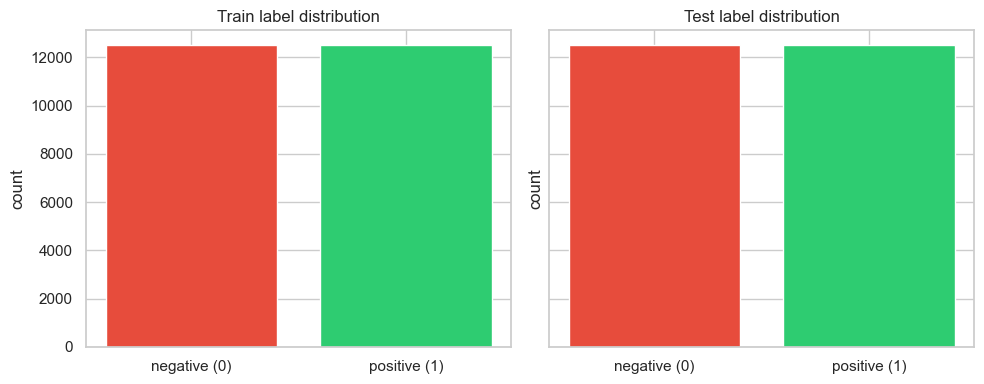

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, df, title in zip(axes, [train_df, test_df], ["Train", "Test"]):
    counts = df["label"].value_counts().sort_index()
    ax.bar(
        ["negative (0)", "positive (1)"], counts.values, color=["#e74c3c", "#2ecc71"]
    )
    ax.set_title(f"{title} label distribution")
    ax.set_ylabel("count")
plt.tight_layout()
plt.show()

## Review length

C:\Users\pkoun\AppData\Local\Temp\ipykernel_33616\3258781190.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df, x="label", y="word_len", ax=axes[1], palette="Set1")
C:\Users\pkoun\AppData\Local\Temp\ipykernel_33616\3258781190.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["negative", "positive"])


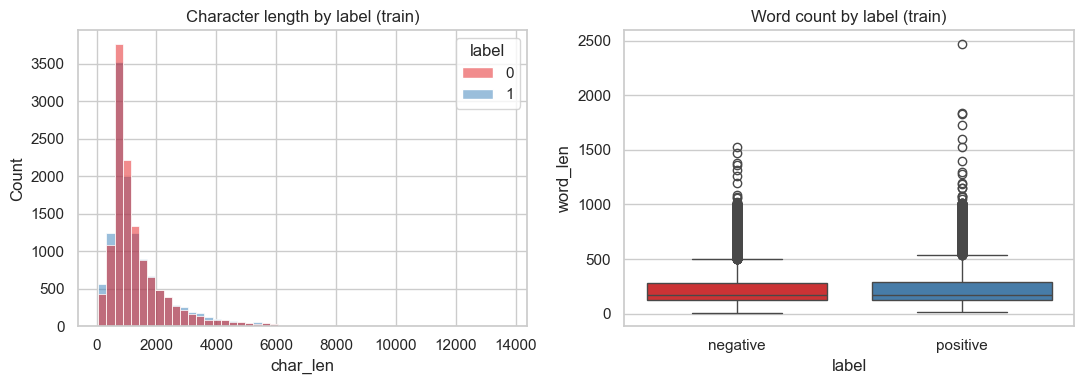

          char_len      word_len
count  25000.00000  25000.000000
mean    1325.06964    233.787200
std     1003.13367    173.733032
min       52.00000     10.000000
25%      702.00000    127.000000
50%      979.00000    174.000000
75%     1614.00000    284.000000
max    13704.00000   2470.000000


In [22]:
train_df["char_len"] = train_df["text"].str.len()
train_df["word_len"] = train_df["text"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(
    data=train_df, x="char_len", hue="label", bins=50, ax=axes[0], palette="Set1"
)
axes[0].set_title("Character length by label (train)")
sns.boxplot(data=train_df, x="label", y="word_len", ax=axes[1], palette="Set1")
axes[1].set_title("Word count by label (train)")
axes[1].set_xticklabels(["negative", "positive"])
plt.tight_layout()
plt.show()

print(train_df[["char_len", "word_len"]].describe())

## Data quality checks

In [23]:
for name, df in [("train", train_df), ("test", test_df)]:
    empty = (df["text"].str.strip() == "").sum()
    dupes = df.duplicated(subset=["text"]).sum()
    html = df["text"].str.contains(r"<br", case=False, regex=True).sum()
    print(f"{name}: empty={empty}, duplicate texts={dupes}, contains <br>={html}")

train: empty=0, duplicate texts=96, contains <br>=14665
test: empty=0, duplicate texts=199, contains <br>=14535


## Discriminative unigrams by class (train)

Uses the same `clean_for_sklearn` preprocessing as the sklearn pipeline (lowercase + HTML strip). Stopwords = sklearn `ENGLISH_STOP_WORDS` minus sentiment cues (`not`, `but`, …) plus domain noise (`film`, `movie`, …).

Each side ranks words by **class-specific skew** (rate in target class / rate in other class), so scores are always **> 1** on both charts — higher means stronger association with that class.

Negative-skewed (neg/pos > 1): [('unfunny', 14.452606082659086), ('waste', 14.440808036877327), ('pointless', 11.827166811838481), ('redeeming', 10.728817370602926), ('worst', 10.273211820094437), ('lousy', 9.95991024896392), ('laughable', 9.771371722227071), ('awful', 9.63162962508638), ('poorly', 9.453225725051944), ('lame', 7.550041417581108), ('sucks', 7.3733066917703045), ('horrible', 6.977273521136033), ('pathetic', 6.797386989844178), ('wasted', 6.527322456240941), ('crap', 6.453088615907283)]
Positive-skewed (pos/neg > 1): [('wonderfully', 7.2833340431963), ('delightful', 5.993576973046954), ('beautifully', 5.615817242941938), ('underrated', 5.392252325962074), ('superb', 5.318130237851666), ('touching', 4.940328793971668), ('brilliantly', 4.759215631400756), ('friendship', 4.628467949219417), ('stewart', 4.618117091046727), ('wonderful', 4.587330263850166), ('magnificent', 4.533391645546247), ('finest', 4.530407187583412), ('terrific', 4.386081861483241), ('fantastic', 4.34104

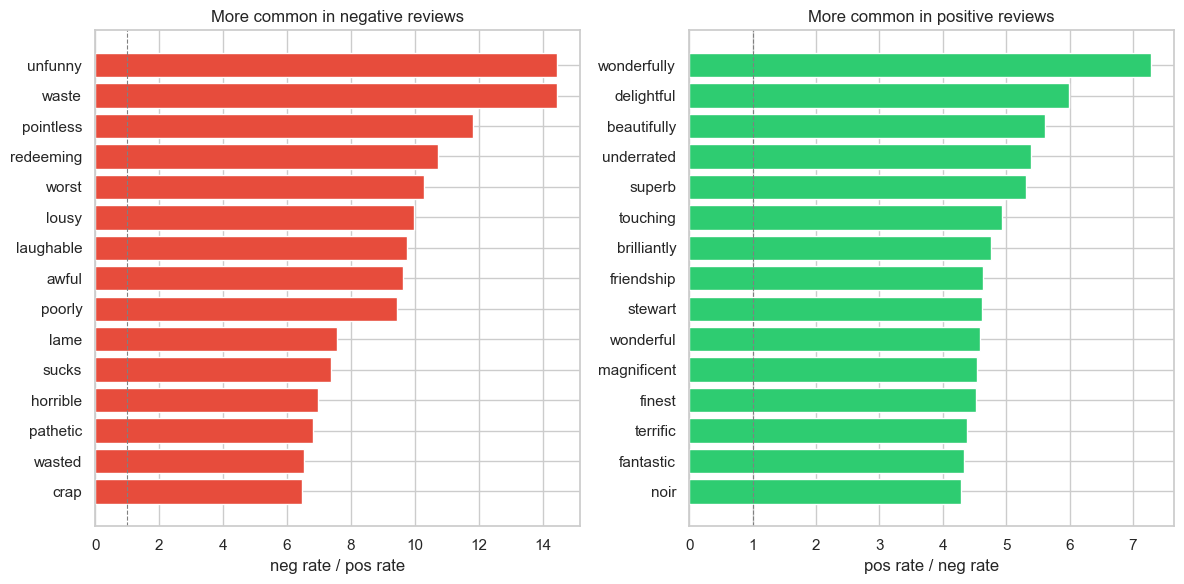

In [24]:
TOKEN_RE = re.compile(r"[a-z']+")

SENTIMENT_KEEP = {"not", "no", "nor", "never", "neither", "but", "very", "too", "more"}
DOMAIN_STOP = {"film", "movie", "films", "movies", "story", "character", "br"}
EDA_STOP = set(ENGLISH_STOP_WORDS) - SENTIMENT_KEEP | DOMAIN_STOP


def tokenize(clean_text: str) -> list[str]:
    return [
        w for w in TOKEN_RE.findall(clean_text) if len(w) >= 3 and w not in EDA_STOP
    ]


def class_token_counts(texts: pd.Series) -> Counter:
    counter: Counter = Counter()
    for text in texts:
        counter.update(tokenize(clean_for_sklearn(text)))
    return counter


def distinctive_words(
    neg_counts: Counter,
    pos_counts: Counter,
    n: int = 15,
    min_class_count: int = 200,
) -> tuple[list[tuple[str, float]], list[tuple[str, float]]]:
    """Scores are > 1 when a word favors that class."""
    neg_total = sum(neg_counts.values())
    pos_total = sum(pos_counts.values())
    neg_scores: list[tuple[str, float]] = []
    pos_scores: list[tuple[str, float]] = []

    for word in set(neg_counts) | set(pos_counts):
        nc, pc = neg_counts[word], pos_counts[word]
        neg_rate = (nc + 1) / neg_total
        pos_rate = (pc + 1) / pos_total

        if nc >= min_class_count:
            neg_scores.append((word, neg_rate / pos_rate))
        if pc >= min_class_count:
            pos_scores.append((word, pos_rate / neg_rate))

    neg_skewed = sorted(neg_scores, key=lambda x: x[1], reverse=True)[:n]
    pos_skewed = sorted(pos_scores, key=lambda x: x[1], reverse=True)[:n]
    return neg_skewed, pos_skewed


neg_texts = train_df.loc[train_df["label"] == 0, "text"]
pos_texts = train_df.loc[train_df["label"] == 1, "text"]
neg_counts = class_token_counts(neg_texts)
pos_counts = class_token_counts(pos_texts)
neg_words, pos_words = distinctive_words(neg_counts, pos_counts)

print("Negative-skewed (neg/pos > 1):", neg_words)
print("Positive-skewed (pos/neg > 1):", pos_words)


def plot_skewed_words(
    words: list[tuple[str, float]], title: str, xlabel: str, color: str, ax
) -> None:
    labels = [w for w, _ in reversed(words)]
    values = [s for _, s in reversed(words)]
    ax.barh(labels, values, color=color)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.axvline(1.0, color="gray", linestyle="--", linewidth=0.8)


fig, axes = plt.subplots(1, 2, figsize=(12, 6))
plot_skewed_words(
    neg_words,
    "More common in negative reviews",
    "neg rate / pos rate",
    "#e74c3c",
    axes[0],
)
plot_skewed_words(
    pos_words,
    "More common in positive reviews",
    "pos rate / neg rate",
    "#2ecc71",
    axes[1],
)
plt.tight_layout()
plt.show()

## Sample reviews

In [25]:
for label, name in [(0, "negative"), (1, "positive")]:
    sample = train_df.loc[train_df["label"] == label, "text"].iloc[0]
    print(f"--- {name} ---\n{sample}\n")

--- negative ---
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and

## Export processed splits

Run the preprocessing module to save `train_fit.csv`, `val.csv`, and `test.csv`.

In [26]:
train_fit, val, test = build_splits()
save_splits(train_fit, val, test)
print(f"train_fit={len(train_fit):,}  val={len(val):,}  test={len(test):,}")

train_fit=21,250  val=3,750  test=25,000
